### ___Multi Response Phylogenetic Mixed Models `MR-PMM` using Markov Chain Monte Carlo generalized linear mixed models `MCMCglmm`___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [53]:
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html

In [54]:
set.seed(2026 - 3 - 9)

suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("MCMCglmm")
    library("nlme")
    library("U.PhyloMaker")
    library("phylolm")
})

### ___1. Phylogeny___
---------------------------

In [4]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/species_averaged_and_logged_continuous_traits_FRED4.csv") # continuous trait averages from FRED 4.0
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [5]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = paste0(traits$F01286, ' ', traits$F01287), genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

[1] "Note: 8 species fail to be binded to the tree."
[1] "Blechnopsis_orientalis"       "Lomaria_discolor"            
[3] "Parablechnum_novae-zelandiae" "Parablechnum_procerum"       
[5] "Pseudodiphasium_volubile"     "Richetia_multiflora"         
[7] "Rubroshorea_acuminata"        "Rubroshorea_leprosula"       


In [6]:
failed_to_bind <- c("Blechnopsis orientalis", "Lomaria discolor", "Parablechnum novae-zelandiae", "Parablechnum procerum", "Pseudodiphasium volubile", "Richetia multiflora", 
    "Rubroshorea acuminata", "Rubroshorea leprosula")

In [22]:
synonyms[synonyms$synonym %in% failed_to_bind, ]

,name,synonym
,<chr>,<chr>
30917,Lycopodium volubile,Pseudodiphasium volubile
50456,Blechnum discolor,Lomaria discolor
65898,Blechnum novae-zelandiae,Parablechnum novae-zelandiae
80587,Blechnum procerum,Parablechnum procerum
86560,Blechnum orientale,Blechnopsis orientalis


In [23]:
# gsub(failed_to_bind, pattern = " \\w*-{0,1}", replacement = '')

traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"

In [24]:
synonyms[synonyms$name %in% failed_to_bind, ]

,name,synonym
,<chr>,<chr>
107576,Richetia multiflora,Doona multiflora
108784,Richetia multiflora,Balanocarpus multiflorus
108785,Richetia multiflora,Shorea multiflora
112890,Rubroshorea acuminata,Shorea acuminata
116883,Rubroshorea leprosula,Shorea leprosula


In [27]:
traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

In [30]:
#---------------------------------
# re run the phylogeny creation
#---------------------------------

species_list <- data.frame(species = paste0(traits$F01286, ' ', traits$F01287), genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [50]:
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301_species.tre") # the phylogeny of the 1301 FRED 4.0 subset species
if (!ape::is.binary(tree)) tree <- ape::multi2di(tree)
stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches

### ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [18]:
# the tutorial uses the R library phylolm, but why????? could've just used nlme::gls
# let's try both

In [19]:
# nlme::gls
corrmat <- ape::corBrownian(phy = phylogeny) # transform the phylogeny into a correlation matrix??
pgls_0 <- nlme::gls(F00727 ~ F00679, data = data, correlation = corrmat) # log(SRL) ~ log(RD) (RD as the predictor of SRL)

Warning message in Initialize.corPhyl(X[[i]], ...):
"No covariate specified, species will be taken as ordered in the data frame. To avoid this message, specify a covariate containing the species names with the 'form' argument."


In [20]:
# don't worry about the waring as our data and phylogeny has been name matched
summary(pgls_0)

Generalized least squares fit by REML
  Model: F00727 ~ F00679 
  Data: data 
       AIC      BIC    logLik
  3807.344 3822.046 -1900.672

Correlation Structure: corBrownian
 Formula: ~1 
 Parameter estimate(s):
numeric(0)

Coefficients:
                Value Std.Error    t-value p-value
(Intercept)  2.603773 3.1017055   0.839465  0.4014
F00679      -1.254196 0.0734152 -17.083601  0.0000

 Correlation: 
       (Intr)
F00679 0.022 

Standardized residuals:
         Min           Q1          Med           Q3          Max 
-1.089832941 -0.073093691 -0.008224465  0.065609870  0.329875443 

Residual standard error: 7.361376 
Degrees of freedom: 995 total; 993 residual

In [24]:
# using phylolm

data_phylolm <- data # making a copy
rownames(data_phylolm) <- data_phylolm$binominal # phylolm requires that the rownames of the data matches with the tips of the phylogeny

pgls_1_brownian <- phylolm::phylolm(F00727 ~ F00679, data = data_phylolm, phy = phylogeny, model = "BM") # lambda fixed to 1
pgls_1_lambda <- phylolm::phylolm(F00727 ~ F00679, data = data_phylolm, phy = phylogeny, model = "lambda") # lambda estimated during the fit???

In [25]:
summary(pgls_1_brownian) # this is very similar to what we got from nlme::gls()


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = data_phylolm, 
    phy = phylogeny, model = "BM")

   AIC logLik 
  3808  -1901 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-8.0227 -0.5381 -0.0605  0.4830  2.4283 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
sigma2: 0.1349366 

Coefficients:
             Estimate    StdErr  t.value p.value    
(Intercept)  2.603773  3.101705   0.8395  0.4014    
F00679      -1.254196  0.073415 -17.0836  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.2271	Adjusted R-squared: 0.2264 

In [26]:
summary(pgls_1_lambda)


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = data_phylolm, 
    phy = phylogeny, model = "lambda")

   AIC logLik 
  2449  -1221 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-8.2950 -0.4969 -0.0456  0.4195  2.6135 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.6740991
sigma2: 0.003957272 

Coefficients:
             Estimate    StdErr  t.value   p.value    
(Intercept)  2.269711  0.467750   4.8524 1.416e-06 ***
F00679      -1.569916  0.063468 -24.7355 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.3812	Adjusted R-squared: 0.3806 

Note: p-values and R-squared are conditional on lambda=0.6740991.

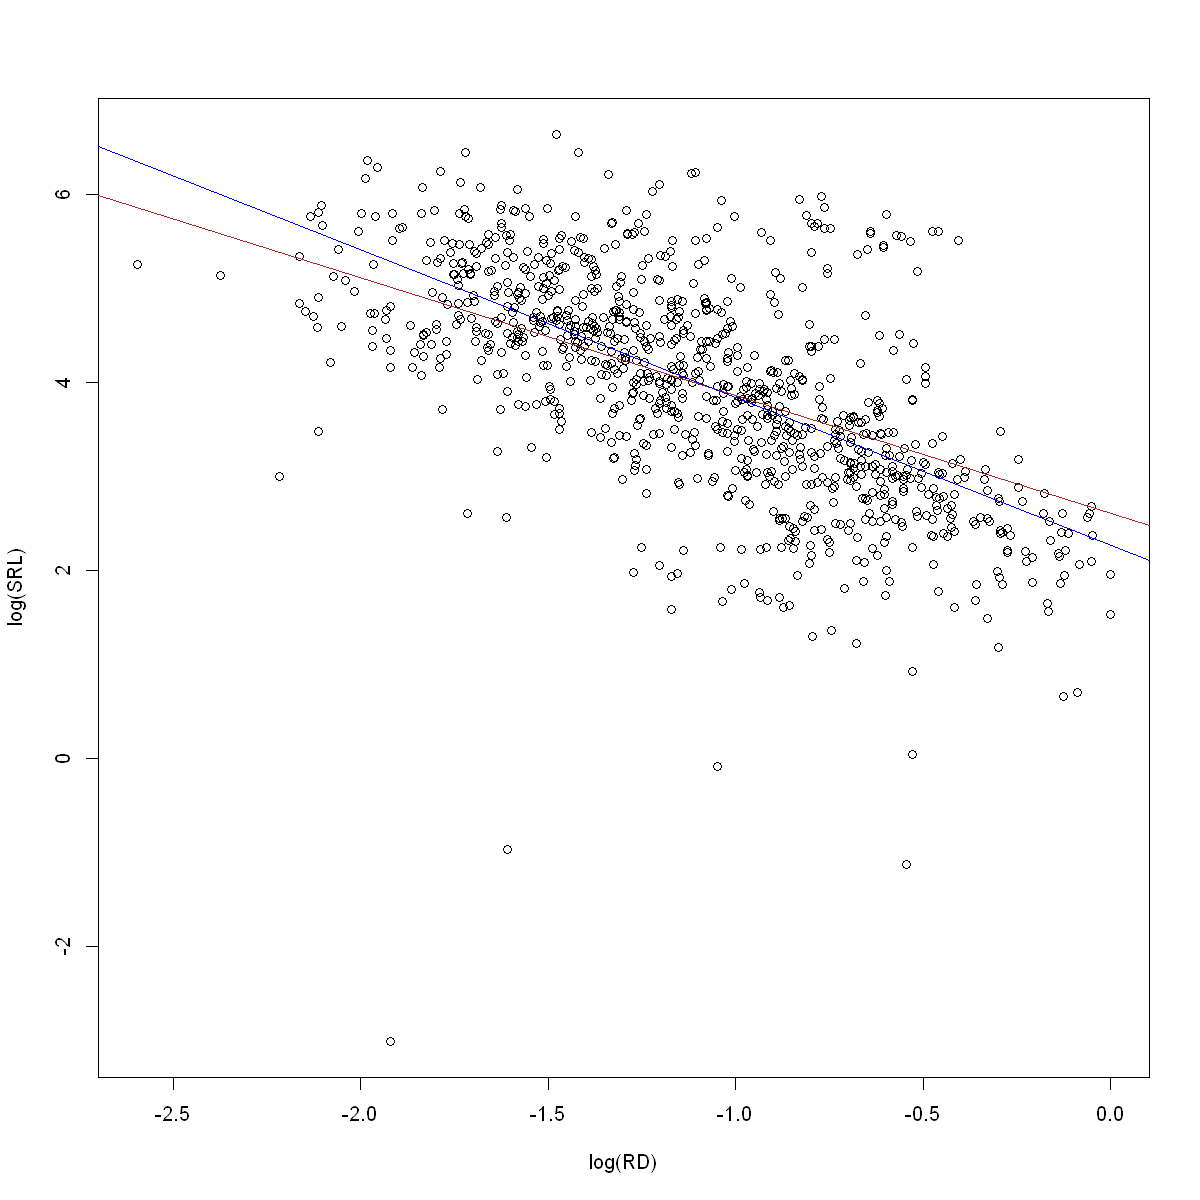

In [43]:
# these are all PGLS models, that account for phylogenetic signal in the response variables

options(repr.plot.width = 10, repr.plot.height = 10)
plot(F00727 ~ F00679, data, xlab = "log(RD)", ylab = "log(SRL)")
abline(pgls_0, col = "red")
abline(pgls_1_brownian, col = "brown") # the results of nlme::gls() and phylolm::phylolm() with 'method' arg set to "BM" are identical :)
abline(pgls_1_lambda, col = "blue")

In [46]:
# what if we fit a regular OLS model to the same data??

lmod <- lm(F00727 ~ F00679, data = data)
summary(lmod)


Call:
lm(formula = F00727 ~ F00679, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.2519 -0.4495  0.0052  0.4657  2.6655 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.21501    0.07453   29.72   <2e-16 ***
F00679      -1.57593    0.06258  -25.18   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9104 on 993 degrees of freedom
Multiple R-squared:  0.3897,	Adjusted R-squared:  0.3891 
F-statistic: 634.2 on 1 and 993 DF,  p-value: < 2.2e-16


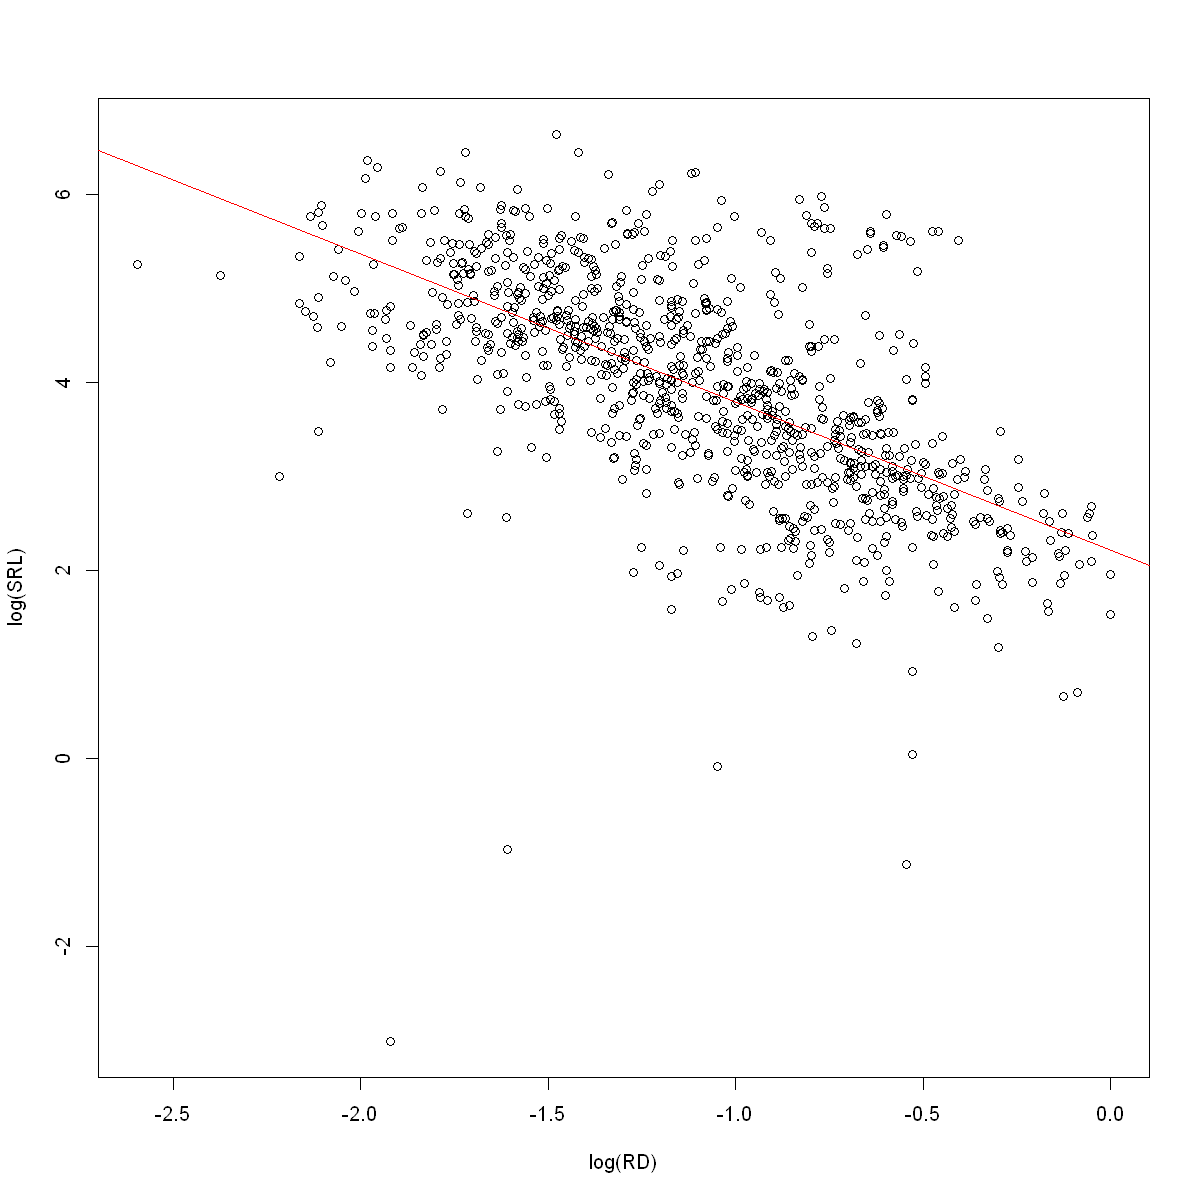

In [47]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot(F00727 ~ F00679, data, xlab = "log(RD)", ylab = "log(SRL)")
abline(lmod, col = "red")

In [8]:
# "By including more diverse species in our phylogeny, we capture deeper splits that represent more meaningful divergences in the genotype and phenotype of extant lineages,
# precisely the effects we intend to model when analysing inter-species data."
# "One consequence of this, is that shallow topology (near the tips) is less informative than deep topology when attempting to infer patterns of phylogenetic niche conservatism, because differences between genera
# are usually more significant than differences between species within genera."

# "For higher taxonomic ranks (e.g. genus), it will usually be possible to derive a unique consensus tree by sampling a single species from each genus and simply pruning off the other tips from the tree.
# This approach may be problematic for lower taxonomic ranks however, because more closely related species are less likely to be monophyletic with respect to the taxonomic rank in question.
# Even in such cases, we can easily account for this phylogenetic uncertainty by randomly sampling topologies at the specified rank and fitting our models over this sample of trees."

In [16]:
# sample the phylogeny repeatedly, with one randomly chosen species per genera

NUNIQUE_GENERA <- length(unique(data$F01286)) # number of unique genera in our phylogeny
NSAMPLES = 100 # number of times to sample the original phylogeny
sampled_phylogenies <- list() # sampled sub phylogeneies with genera at tips
sampled_vcvs <- list()

for (i in 1:NSAMPLES) {
    sampled_species <- mapply(split.data.frame(data[, c("binominal", "F01286")], ~F01286), FUN = function(df) sample(df$binominal, 1)) # this is a vector of one randomly sampled species per each genera in the phylogeny
    subphylogeny <- ape::keep.tip(phy = phylogeny, tip = unname(sampled_species), trim.internal = TRUE) # trimmed phylogeny with one randomly sampled species per genus
    stopifnot(length(subphylogeny$tip.label)==NUNIQUE_GENERA)
                                     
    if(!ape::is.binary(subphylogeny)) subphylogeny <- ape::multi2di(subphylogeny) # make bifucracting if not already
    if(!ape::is.ultrametric(subphylogeny)) subphylogeny <- phytools::force.ultrametric(subphylogeny, method = "extend", message = FALSE) # make ultrametric if not already

    subphylogeny$tip.label <- gsub(subphylogeny$tip.label, pattern = "_[-a-z]+", replacement = '', fixed = FALSE) # replace the tip labels (binominal names) with genus names
    stopifnot(length(setdiff(subphylogeny$tip.label, unique(data$F01286))) == 0)
                              
    sampled_phylogenies[[i]] <- subphylogeny
    sampled_vcvs[[i]] <- ape::vcv.phylo(phy = subphylogeny, corr = TRUE) # computes the expected variances and covariances of a continuous phenotype assuming it evolves under a Brownian motion model
}

stopifnot(length(sampled_phylogenies) == length(sampled_vcvs))

In [ ]:
# create list of C matrices and dfs for use with brm_multiple() - DONT KNOW WTF THESE ARE????